<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/Programacion1Sem/ProyectoProgADAP_261540.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display: flex; justify-content: space-between; align-items: center; width: 100%; gap: 1000px;">
  <img src="https://drive.google.com/uc?export=view&id=14RsW7oARDpjNHWBCObjV4UV8jq7TbdnY"
       alt="Logo Izquierdo" style="height:80px;">
  <img src="https://drive.google.com/uc?export=view&id=1sFuh9EmSszCgXmrbSENkFsgTVrplKaen"
       alt="Logo Derecho" style="height:80px;">
</div>


## **Análisis de factores de Riesgo para la predicción de ataques cardiacos usando Modelos Estadísticos**

**Alumno:** *Marco Antonio Muñoz Quiroz*

**Matrícula:** *261540*

**Fecha:** *30 de septiembre de 2025*

# **Introducción**

Las enfermedades cardiovasculares representan una de las principales causas de muerte a nivel mundial. Sin embargo, su diagnóstico temprano y la identificación de factores de riesgo permiten reducir complicaciones y mejorar la calidad de vida de los pacientes. El problema que se busca abordar con este dataset es la detección temprana de la presencia o ausencia de enfermedad cardiaca en pacientes, a partir de variables clínicas y de laboratorio.

El objetivo general es esarrollar un análisis exploratorio y predictivo del dataset de enfermedades cardíacas de Cleveland con el fin de identificar patrones, correlaciones y variables relevantes que permitan apoyar el diagnóstico temprano de enfermedad cardiaca.
Especificamente probar modelos de clasificación predictiva (por ejemplo, regresión logística, árboles de decisión o k-NN) para estimar la probabilidad de que un paciente presente enfermedad cardíaca.

El dataset "Heart Disease Cleveland" es uno de los más usados en investigaciones académicas y prácticas de machine learning. Fue recopilado originalmente por el Cleveland Clinic Foundation y contiene información de pacientes con variables demográficas (edad, sexo), clínicas (tipo de dolor en el pecho, presión arterial en reposo, colesterol sérico, etc.) y resultados de pruebas (electrocardiograma, frecuencia cardíaca máxima, angina inducida por ejercicio, entre otros).

Este contexto lo convierte en una base de datos idónea para:

- Investigar factores de riesgo clínicos.

- Evaluar modelos de predicción médica.

- Contribuir a la prevención mediante herramientas de apoyo a la decisión clínica.


# **Descripcion del dataset**

El dataset proviene del Cleveland Clinic Foundation, recopilado originalmente como parte de los Heart Disease Databases mantenidos por la University of California, Irvine (UCI Machine Learning Repository). Es uno de los conjuntos más usados en investigación académica y enseñanza de machine learning aplicada a salud.

- https://www.kaggle.com/code/therealoise/heart-disease-prediction-lr-rfc/notebook

Número de registros y variables:

- Registros (filas): alrededor de 297 pacientes
- Variables (columnas): 14 variables

descripcion de variables:

- **age**: Edad del paciente (en años)
- **sex**: Sexo (0 = mujer, 1 = hombre)
- **cp**: Tipo de dolor en el pecho (angina típica, atípica, dolor no anginoso, asintomático)
- **trestbps**: Presión arterial en reposo (mm Hg)
- **chol**: Colesterol sérico (mg/dl)
- **fbs**: Glucosa en ayunas (1 si > 120 mg/dl, 0 en caso contrario)
- **restecg**: Resultados del electrocardiograma en reposo
- **thalach**: Frecuencia cardiaca máxima alcanzada
- **exang**: Angina inducida por ejercicio (1 = sí, 0 = no)
- **oldpeak**: Depresión del ST inducida por el ejercicio
- **slope**: Pendiente del segmento ST en el electrocardiograma
- **ca**: Número de vasos principales coloreados por fluoroscopia
- **thal**: Estado de la variable talasemia (normal, defecto fijo, defecto reversible)
- **condition** (target): Variable dependiente; indica la presencia (1) o ausencia (0) de enfermedad cardíaca


# **Preguntas de análisis descriptivo**

1. Edad promedio, mínima y máxima de los pacientes

    - Edad promedio: ≈ 54.5 años
    - Edad mínima: 29 años
    - Edad máxima: 77 años

2. Distribución de la población por sexo

    - Hombres (1): 201 pacientes
    - Mujeres (0): 96 pacientes
    - 67.7% hombres y 32.3% mujeres.

3. Proporción de pacientes con enfermedad cardíaca

    - Sin enfermedad (0): 53.9% de los pacientes
    - Con enfermedad (1): 46.1% de los pacientes

4. Presión arterial en reposo promedio y variación según enfermedad

    - Promedio general: ≈ 131.7 mm Hg
    - Pacientes sin enfermedad (0): ≈ 129.2 mm Hg
    - Pacientes con enfermedad (1): ≈ 134.6 mm Hg

    Se observa que los pacientes con enfermedad cardíaca tienden a tener una presión arterial en reposo ligeramente más alta que los pacientes sanos.

5. Distribución del colesterol sérico

    - Número de registros válidos: 297
    - Promedio: ≈ 247.4 mg/dl
    - Desviación estándar: ≈ 52 mg/dl
    - Mínimo: 126 mg/dl
    - Máximo: 564 mg/dl

    El colesterol presenta una distribución amplia y con valores muy altos en algunos pacientes (outliers), lo cual puede influir en la condición cardíaca.

6. Frecuencia cardíaca máxima promedio y relación con enfermedad

    - Promedio general: ≈ 149.6 latidos/minuto
    - Pacientes sin enfermedad (0): ≈ 158.6 lpm
    - Pacientes con enfermedad (1): ≈ 139.1 lpm

    Los pacientes con enfermedad cardíaca alcanzan en promedio una frecuencia cardíaca máxima significativamente menor, lo que sugiere limitaciones cardiovasculares.



##  **Métricas de calidad de los datos**

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

In [30]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Semestre1/Programacion/Proyecto/heart_cleveland_upload.csv', sep=',')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,40,1,3,152,223,0,0,181,0,0.0,0,0,2,1
293,39,1,3,118,219,0,0,140,0,1.2,1,0,2,1
294,35,1,3,120,198,0,0,130,1,1.6,1,0,2,1
295,35,0,3,138,183,0,0,182,0,1.4,0,0,0,0


In [31]:
# Defino esta funcion solo para imprimir de una forma mas elegante los print("texto")
def print_box(titulo: str):
    ancho = len(titulo) + 20
    print("=" * ancho)
    print(titulo.center(ancho))
    print("=" * ancho)
    print("\n")

In [32]:
import warnings
warnings.filterwarnings("ignore")

In [33]:
# Descripcion basica
print_box("Valores faltantes")
print(df.isnull().sum())

print_box("Duplicados")
print(df.duplicated().sum())

print_box("Tipos de datos")
print(df.dtypes)

          Valores faltantes          


age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64
          Duplicados          


0
          Tipos de datos          


age            int64
sex            int64
cp             int64
trestbps       int64
chol           int64
fbs            int64
restecg        int64
thalach        int64
exang          int64
oldpeak      float64
slope          int64
ca             int64
thal           int64
condition      int64
dtype: object


In [34]:
# Conversion al tipo correcto de variables

print("Proceso:")
# Defino listas de variables según su naturaleza
print("Definición de grupos de variables")
binarias = ["sex", "fbs", "exang", "condition"]
categoricas_nominales = ["cp", "restecg", "slope", "thal"]
cuantitativas_enteras = ["age", "trestbps", "chol", "thalach", "ca"]
cuantitativas_reales = ["oldpeak"]


# Transformo variables cuantitativas enteras a Int64
print("Transformación de variables cuantitativas enteras")
for c in cuantitativas_enteras:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")


# Transformo variables cuantitativas reales a Float64
print("Transformación de variables cuantitativas reales")
for c in cuantitativas_reales:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Float64")


# Transformo variables binarias a categoría
print("Transformación de variables binarias a categoría")
for c in binarias:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64").astype("category")


# Transformo variables categóricas nominales a category
print("Transformación de variables categóricas nominales")
for c in categoricas_nominales:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64").astype("category")

# Resumen de tipos finales
print_box("Tipos de variables finales")
print(df.dtypes)

Proceso:
Definición de grupos de variables
Transformación de variables cuantitativas enteras
Transformación de variables cuantitativas reales
Transformación de variables binarias a categoría
Transformación de variables categóricas nominales
          Tipos de variables finales          


age             Int64
sex          category
cp           category
trestbps        Int64
chol            Int64
fbs          category
restecg      category
thalach         Int64
exang        category
oldpeak       Float64
slope        category
ca              Int64
thal         category
condition    category
dtype: object


In [35]:
# Renombramos las columnas a nombres mas entendibles
print_box("Renombrando columnas a inglés más descriptivo")

rename_dict = {
    "age": "age_years",
    "sex": "sex",
    "cp": "chest_pain_type",
    "trestbps": "resting_blood_pressure",
    "chol": "serum_cholesterol",
    "fbs": "fasting_blood_sugar",
    "restecg": "resting_ecg",
    "thalach": "max_heart_rate",
    "exang": "exercise_induced_angina",
    "oldpeak": "st_depression",
    "slope": "st_slope",
    "ca": "num_major_vessels",
    "thal": "thalassemia",
    "condition": "heart_disease"
}

df = df.rename(columns=rename_dict)

          Renombrando columnas a inglés más descriptivo          




In [36]:
# Mapeamos columnas categoricas y mostramos su interpretacion

mappings = {
    "sex": {0: "female", 1: "male"},
    "chest_pain_type": {
        0: "typical_angina", 1: "atypical_angina",
        2: "non_anginal_pain", 3: "asymptomatic"
    },
    "fasting_blood_sugar": {0: "false", 1: "true"},
    "resting_ecg": {
        0: "normal", 1: "st_t_abnormality",
        2: "left_ventricular_hypertrophy"
    },
    "exercise_induced_angina": {0: "no", 1: "yes"},
    "st_slope": {0: "upsloping", 1: "flat", 2: "downsloping"},
    "thalassemia": {0: "normal", 1: "fixed_defect", 2: "reversible_defect"},
    "heart_disease": {0: "no_disease", 1: "disease"}
}

rows = []
unmapped_report = []

for col, mp in mappings.items():
    if col not in df.columns:
        continue

    # Tomo sólo valores que realmente existen en el DataFrame (posibles valores "presentes")
    present_vals = pd.Series(df[col].dropna().unique()).sort_values().tolist()

    # Checo si hay valores en el DataFrame que no están en el mapping
    not_mapped = sorted(set(present_vals) - set(mp.keys()))
    if not_mapped:
        unmapped_report.append((col, not_mapped))

    for v in present_vals:
        rows.append({
            "variable": col,
            "numeric_value_present": v,
            "mapped_label": mp.get(v, "<UNMAPPED>")
        })

tabla_map = pd.DataFrame(rows, columns=["variable", "numeric_value_present", "mapped_label"])

# Imprimo la tabla completa
print_box("Tabla de mapeos (valores presentes y sus etiquetas)")
print(tabla_map.to_string(index=False, line_width=1000))

# Aviso si encontré códigos sin mapear
if unmapped_report:
    print_box("Advertencias: valores no mapeados detectados")
    for col, vals in unmapped_report:
        print(f"- {col}: valores no mapeados -> {vals}")
else:
    print_box("Validación de mapeos")
    print("Todos los valores presentes en el DataFrame están cubiertos por los diccionarios de mapeo.")


          Tabla de mapeos (valores presentes y sus etiquetas)          


               variable  numeric_value_present                 mapped_label
                    sex                      0                       female
                    sex                      1                         male
        chest_pain_type                      0               typical_angina
        chest_pain_type                      1              atypical_angina
        chest_pain_type                      2             non_anginal_pain
        chest_pain_type                      3                 asymptomatic
    fasting_blood_sugar                      0                        false
    fasting_blood_sugar                      1                         true
            resting_ecg                      0                       normal
            resting_ecg                      1             st_t_abnormality
            resting_ecg                      2 left_ventricular_hypertrophy
exercise_induc

## **Análisis descriptivo de los datos**

In [37]:
print_box("Vista general del dataset")
print(df.head(20).to_string(index=False, line_width=1000))
print_box("Dimensiones")
print(df.shape)

          Vista general del dataset          


 age_years sex chest_pain_type  resting_blood_pressure  serum_cholesterol fasting_blood_sugar resting_ecg  max_heart_rate exercise_induced_angina  st_depression st_slope  num_major_vessels thalassemia heart_disease
        69   1               0                     160                234                   1           2             131                       0            0.1        1                  1           0             0
        69   0               0                     140                239                   0           0             151                       0            1.8        0                  2           0             0
        66   0               0                     150                226                   0           0             114                       0            2.6        2                  0           0             0
        65   1               0                     138                282                   

In [38]:
print_box("Estadísticas descriptivas generales con tipo de variable")
tipos_var = {
    "age": "numérica_entera",
    "sex": "binaria",
    "cp": "categórica_nominal",
    "trestbps": "numérica_entera",
    "chol": "numérica_entera",
    "fbs": "binaria",
    "restecg": "categórica_nominal",
    "thalach": "numérica_entera",
    "exang": "binaria",
    "oldpeak": "numérica_real",
    "slope": "categórica_nominal",
    "ca": "numérica_discreta",
    "thal": "categórica_nominal",
    "condition": "binaria"
}

desc = df.describe(include="all").T.reset_index().rename(columns={"index": "columna"})
desc.insert(1, "tipo_variable", desc["columna"].map(tipos_var))
print(desc.to_string(index=False, line_width=1000))

          Estadísticas descriptivas generales con tipo de variable          


                columna tipo_variable  count unique  top   freq        mean        std    min    25%    50%    75%    max
              age_years           NaN  297.0   <NA> <NA>   <NA>   54.542088   9.049736   29.0   48.0   56.0   61.0   77.0
                    sex       binaria  297.0    2.0  1.0  201.0         NaN        NaN    NaN    NaN    NaN    NaN    NaN
        chest_pain_type           NaN  297.0    4.0  3.0  142.0         NaN        NaN    NaN    NaN    NaN    NaN    NaN
 resting_blood_pressure           NaN  297.0   <NA> <NA>   <NA>  131.693603  17.762806   94.0  120.0  130.0  140.0  200.0
      serum_cholesterol           NaN  297.0   <NA> <NA>   <NA>  247.350168  51.997583  126.0  211.0  243.0  276.0  564.0
    fasting_blood_sugar           NaN  297.0    2.0  0.0  254.0         NaN        NaN    NaN    NaN    NaN    NaN    NaN
            resting_ecg           NaN  297.0    3.0  0.0  147.0    

          Distribución de la variable objetivo          


heart_disease
0    53.872054
1    46.127946
Name: proportion, dtype: float64


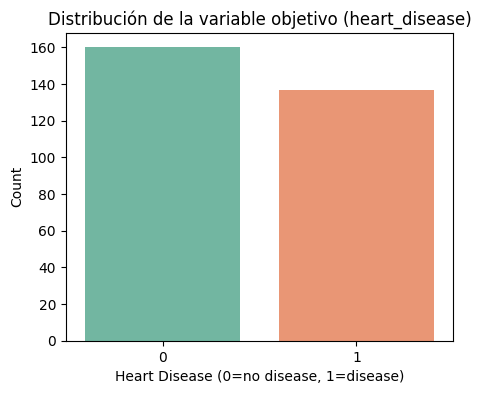

In [39]:
print_box("Distribución de la variable objetivo")
print(df["heart_disease"].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
sns.countplot(x="heart_disease", data=df, palette="Set2")
plt.title("Distribución de la variable objetivo (heart_disease)")
plt.xlabel("Heart Disease (0=no disease, 1=disease)")
plt.ylabel("Count")
plt.show()


          Histogramas de variables numéricas          




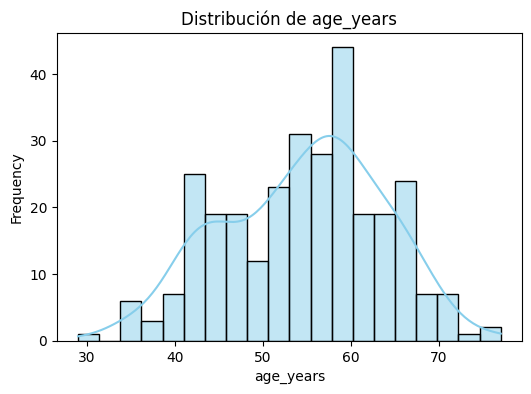

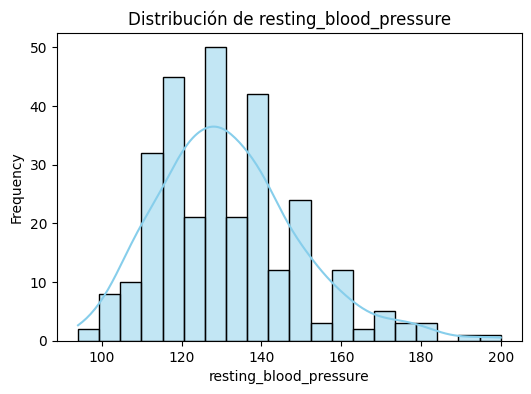

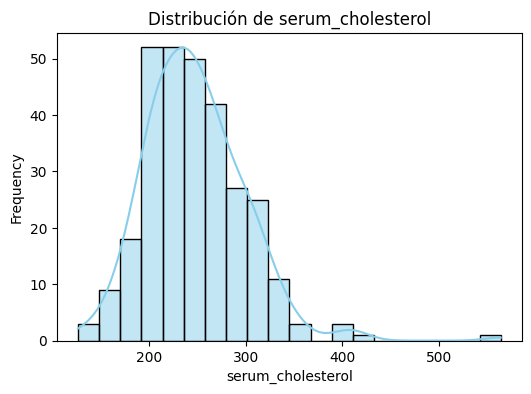

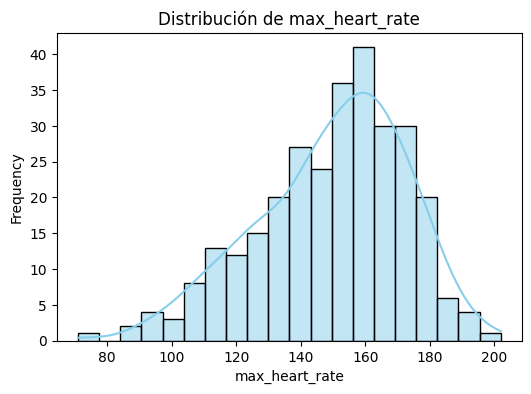

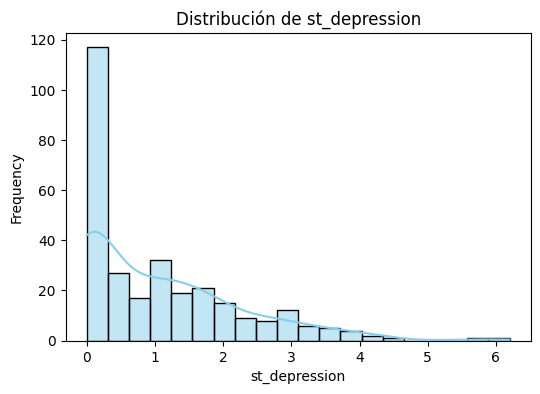

In [40]:
print_box("Histogramas de variables numéricas")

# Lista actualizada con nombres renombrados
numericas = ["age_years", "resting_blood_pressure", "serum_cholesterol",
             "max_heart_rate", "st_depression"]

for col in numericas:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True, color="skyblue", edgecolor="black")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

          Distribuciones de variables categóricas          




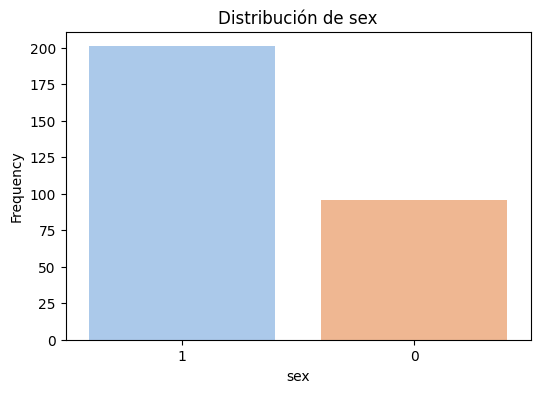

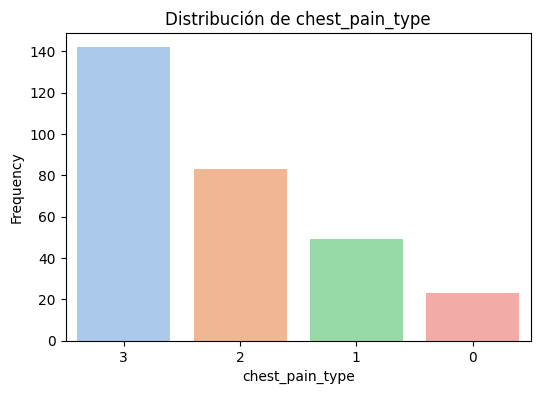

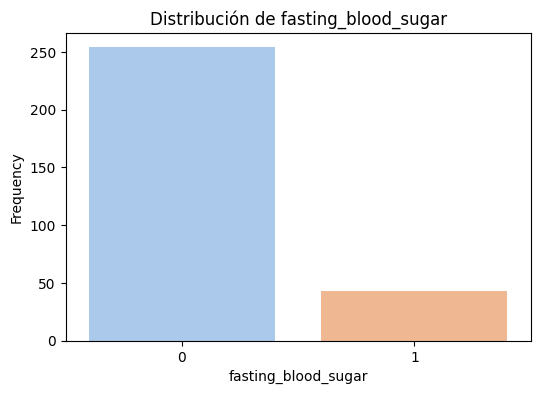

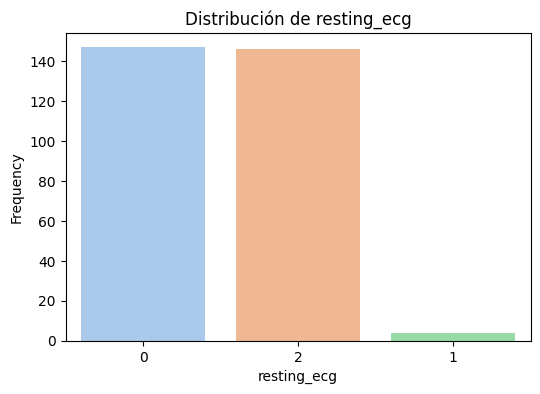

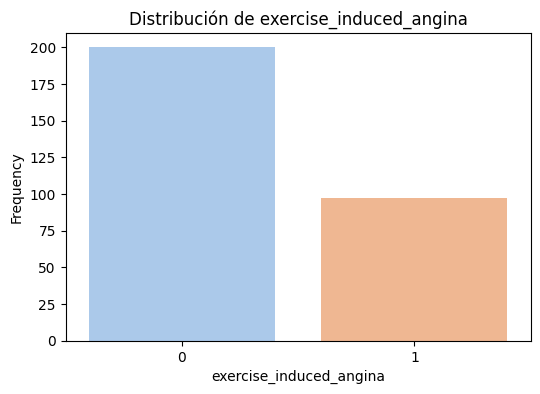

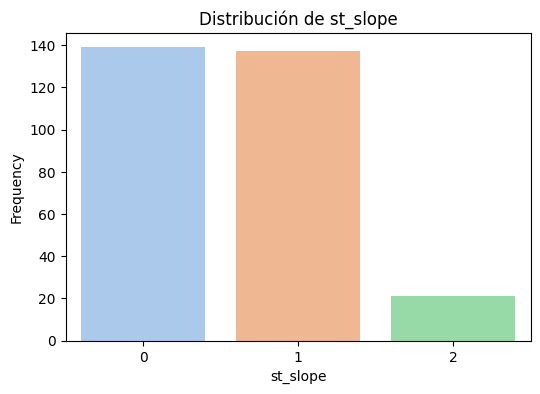

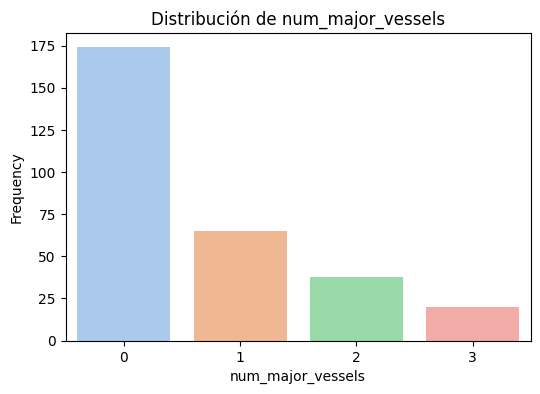

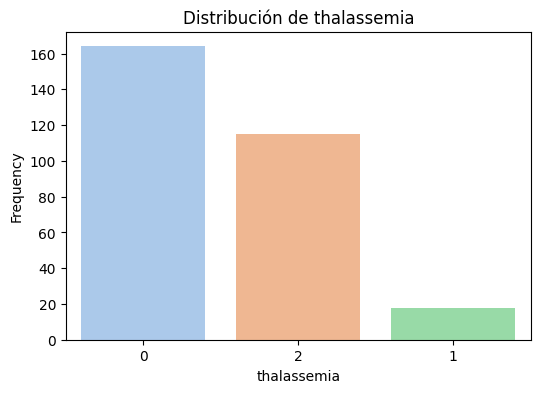

In [41]:
print_box("Distribuciones de variables categóricas")

# Lista actualizada con los nombres nuevos en inglés
categoricas = ["sex", "chest_pain_type", "fasting_blood_sugar", "resting_ecg",
               "exercise_induced_angina", "st_slope", "num_major_vessels", "thalassemia"]

for col in categoricas:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, palette="pastel", order=df[col].value_counts().index)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


          Comparación de variables numéricas según la condición cardíaca          




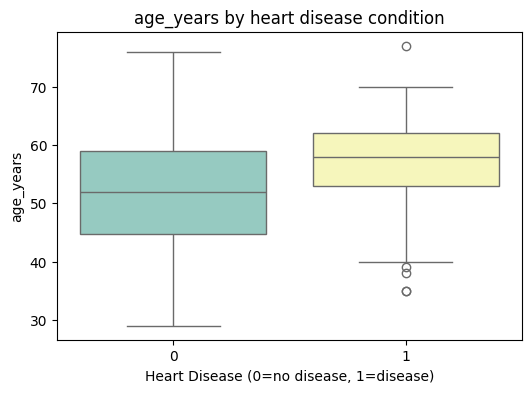

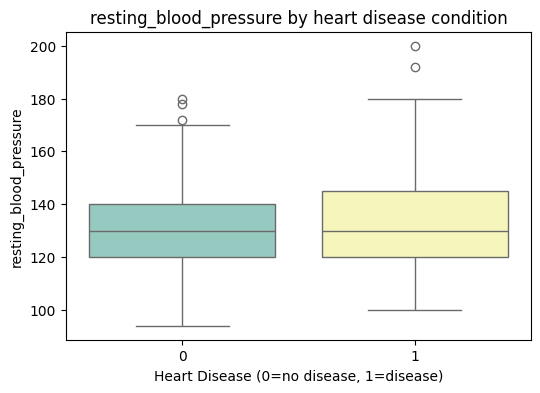

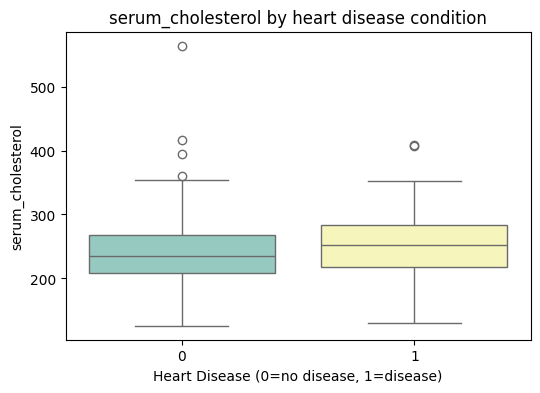

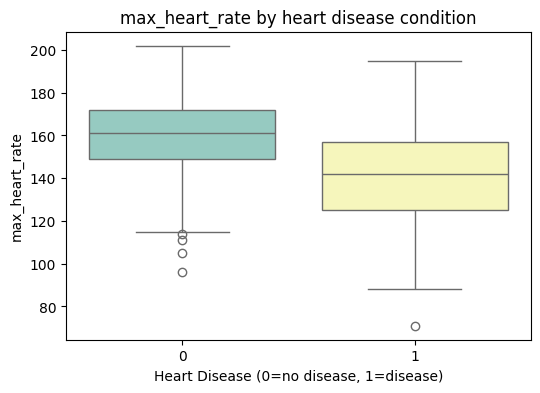

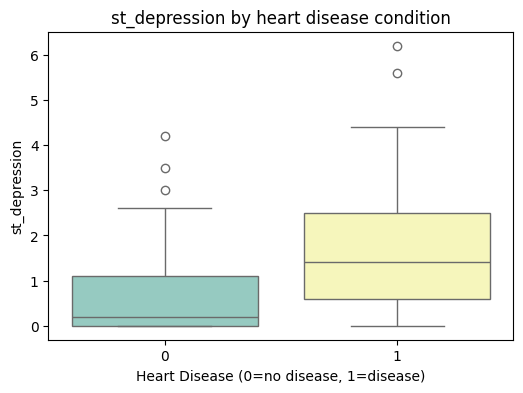

In [42]:
print_box("Comparación de variables numéricas según la condición cardíaca")

# Lista numéricas actualizada
numericas = ["age_years", "resting_blood_pressure", "serum_cholesterol",
             "max_heart_rate", "st_depression"]

for col in numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="heart_disease", y=col, data=df, palette="Set3")
    plt.title(f"{col} by heart disease condition")
    plt.xlabel("Heart Disease (0=no disease, 1=disease)")
    plt.ylabel(col)
    plt.show()

          Comparación de variables categóricas según la condición cardíaca          



Distribución porcentual de sex según heart_disease:
heart_disease      0      1
sex                        
0              73.96  26.04
1              44.28  55.72


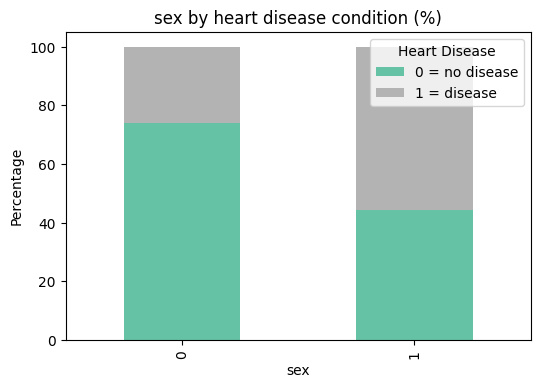


Distribución porcentual de chest_pain_type según heart_disease:
heart_disease        0      1
chest_pain_type              
0                69.57  30.43
1                81.63  18.37
2                78.31  21.69
3                27.46  72.54


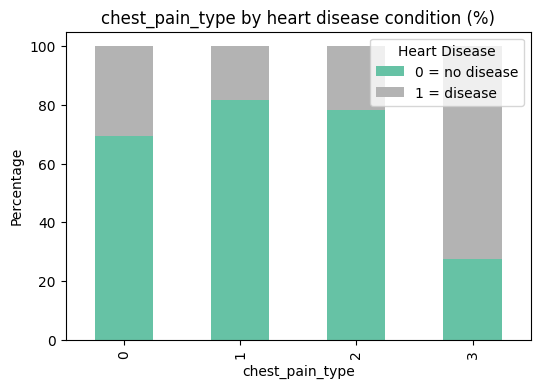


Distribución porcentual de fasting_blood_sugar según heart_disease:
heart_disease            0      1
fasting_blood_sugar              
0                    53.94  46.06
1                    53.49  46.51


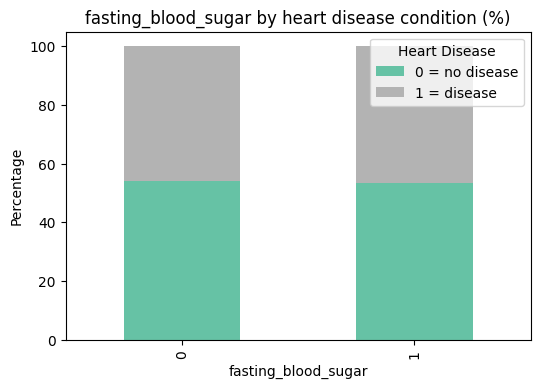


Distribución porcentual de resting_ecg según heart_disease:
heart_disease      0      1
resting_ecg                
0              62.59  37.41
1              25.00  75.00
2              45.89  54.11


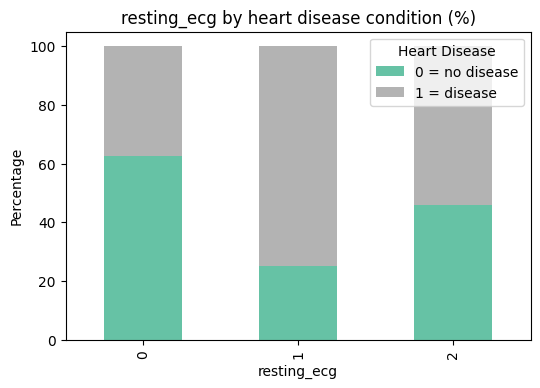


Distribución porcentual de exercise_induced_angina según heart_disease:
heart_disease                0      1
exercise_induced_angina              
0                        68.50  31.50
1                        23.71  76.29


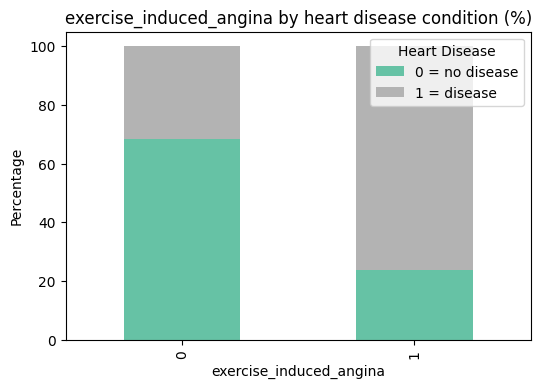


Distribución porcentual de st_slope según heart_disease:
heart_disease      0      1
st_slope                   
0              74.10  25.90
1              35.04  64.96
2              42.86  57.14


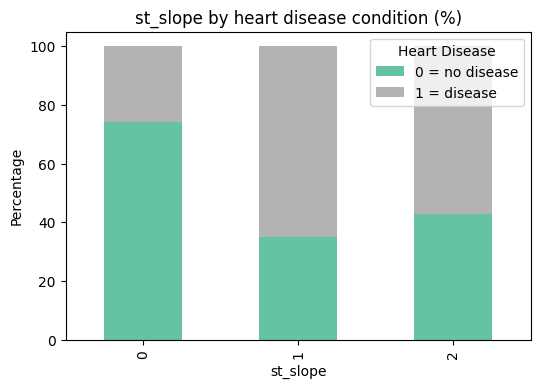


Distribución porcentual de num_major_vessels según heart_disease:
heart_disease          0      1
num_major_vessels              
0                  74.14  25.86
1                  32.31  67.69
2                  18.42  81.58
3                  15.00  85.00


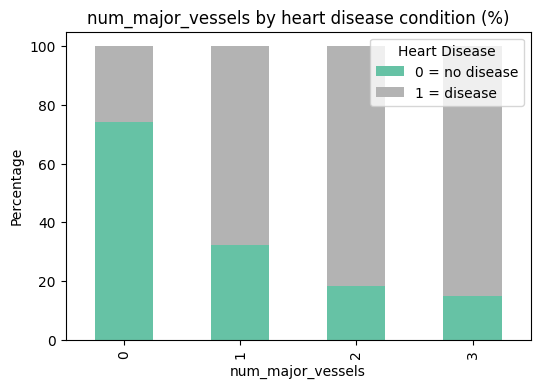


Distribución porcentual de thalassemia según heart_disease:
heart_disease      0      1
thalassemia                
0              77.44  22.56
1              33.33  66.67
2              23.48  76.52


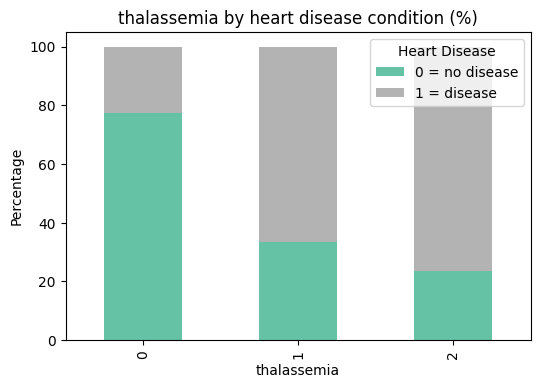

In [43]:
print_box("Comparación de variables categóricas según la condición cardíaca")

# Lista actualizada de variables categóricas
categoricas = ["sex", "chest_pain_type", "fasting_blood_sugar", "resting_ecg",
               "exercise_induced_angina", "st_slope", "num_major_vessels", "thalassemia"]

for col in categoricas:
    ct = pd.crosstab(df[col], df["heart_disease"], normalize="index") * 100
    print(f"\nDistribución porcentual de {col} según heart_disease:")
    print(ct.round(2))

    ct.plot(kind="bar", stacked=True, figsize=(6,4), colormap="Set2")
    plt.title(f"{col} by heart disease condition (%)")
    plt.xlabel(col)
    plt.ylabel("Percentage")
    plt.legend(title="Heart Disease", labels=["0 = no disease", "1 = disease"])
    plt.show()


          Matriz de correlación entre variables numéricas          




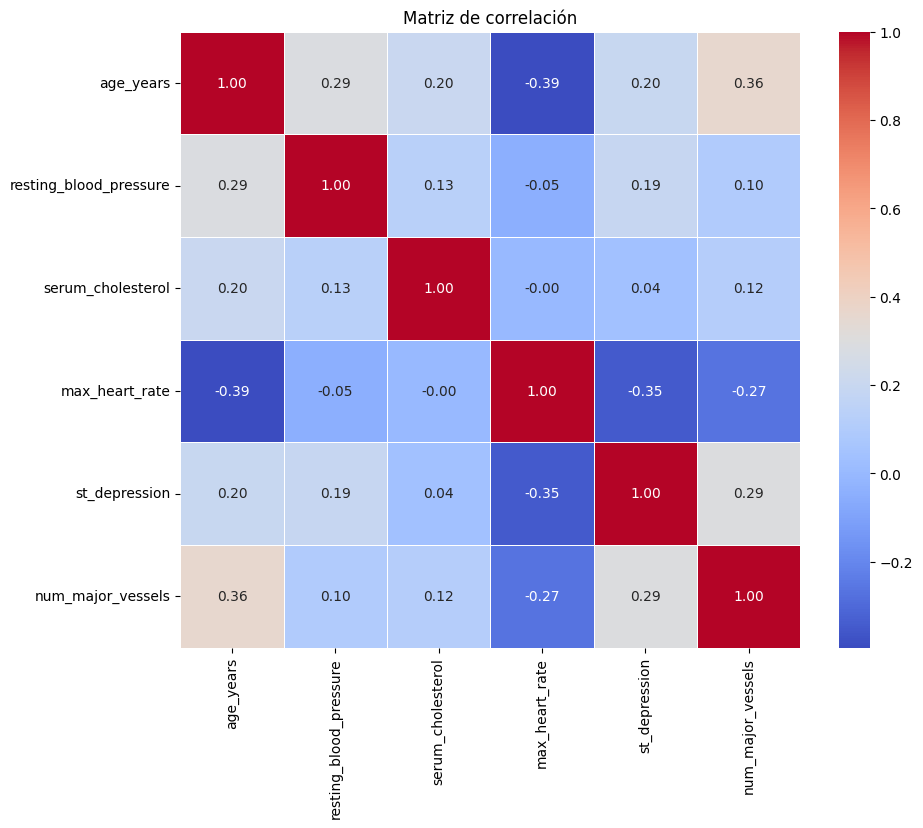

In [44]:
print_box("Matriz de correlación entre variables numéricas")
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlación")
plt.show()

In [45]:
# ===============================================================
# RESUMEN DE CÓMO DETERMINAR NORMALIDAD (Shapiro-Wilk y K-S)
# ===============================================================

# --- Shapiro-Wilk ---
# - Hipótesis nula (H0): los datos provienen de una distribución normal.
# - Interpretación del valor p:
#     * p > 0.05  -> No rechazo H0  -> los datos son compatibles con normalidad.
#     * p <= 0.05 -> Rechazo H0     -> los datos NO son normales.
# - Ventajas:
#     * Muy usado y confiable con muestras pequeñas y medianas (n < 5000).
# - Limitación:
#     * En muestras muy grandes, detecta hasta pequeñas desviaciones y tiende a rechazar normalidad.

# --- Kolmogorov-Smirnov (K-S) ---
# - Hipótesis nula (H0): la distribución de los datos es igual a la distribución teórica especificada (ej. normal estándar).
# - Interpretación del valor p:
#     * p > 0.05  -> No rechazo H0  -> los datos son compatibles con normalidad.
#     * p <= 0.05 -> Rechazo H0     -> los datos NO son normales.
# - IMPORTANTE:
#     * Antes de aplicar K-S contra normal, debo estandarizar los datos (media=0, desviación=1).
#       Si no, casi siempre rechaza H0 aunque los datos sean “casi normales”.
# - Limitaciones:
#     * Con muestras pequeñas tiene baja potencia (no detecta bien no-normalidad).
#     * Con muestras grandes es demasiado sensible (rechaza hasta desviaciones mínimas).

# --- Recomendación práctica ---
# 1. Usar Shapiro-Wilk como prueba principal de normalidad.
# 2. Complementar con K-S (siempre con datos estandarizados).
# 3. Revisar gráficamente con histogramas y Q-Q plots:
#    * Si los puntos siguen la recta en Q-Q plot -> distribución ≈ normal.
#    * Si hay curvaturas o colas muy largas -> no normal.
# 4. Conclusión:
#    * Si Shapiro y K-S dan p > 0.05 y Q-Q plot se ve alineado -> puedo considerar normalidad.
#    * En caso contrario -> asumir que no hay normalidad y usar pruebas no paramétricas.


          Pruebas de normalidad en variables numéricas          




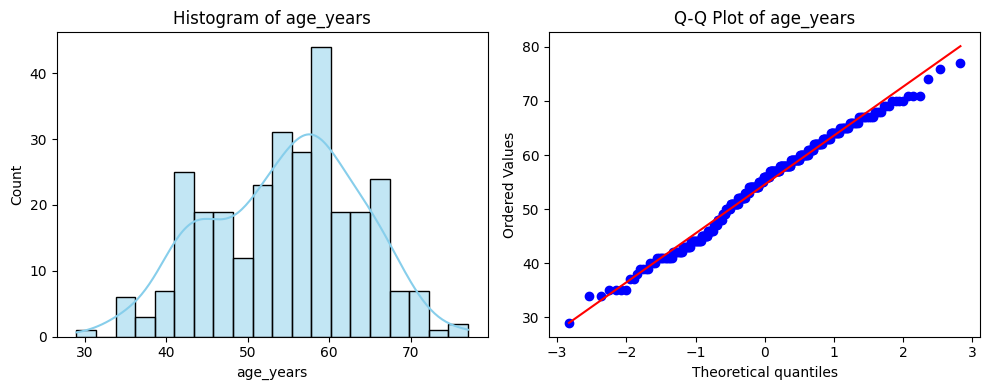

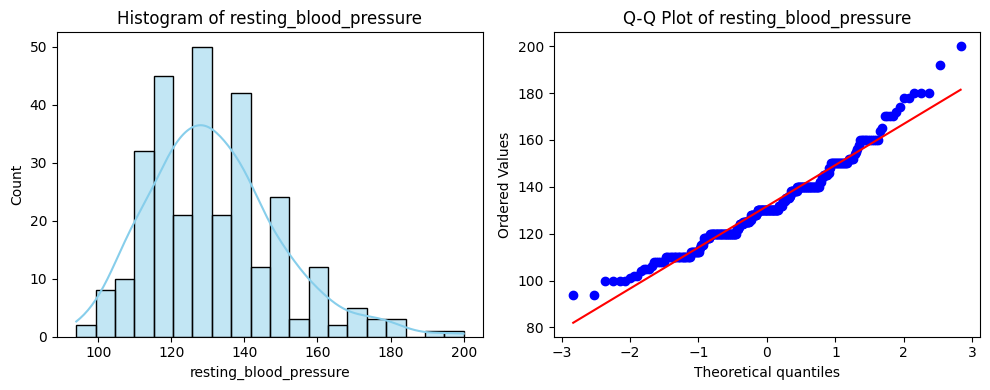

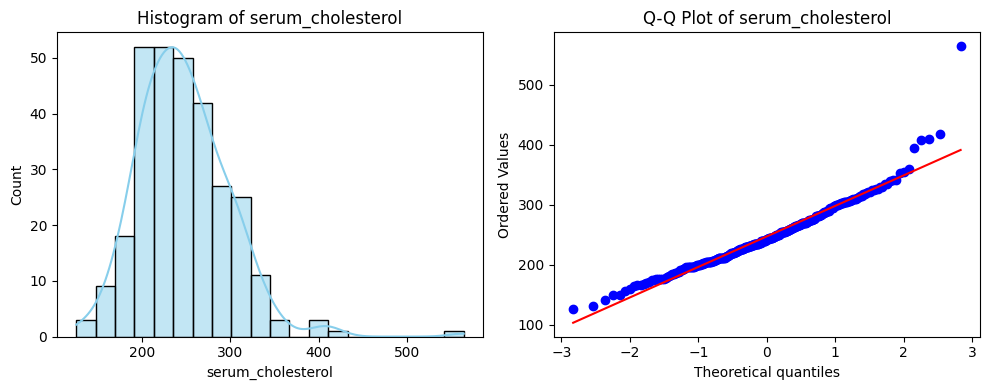

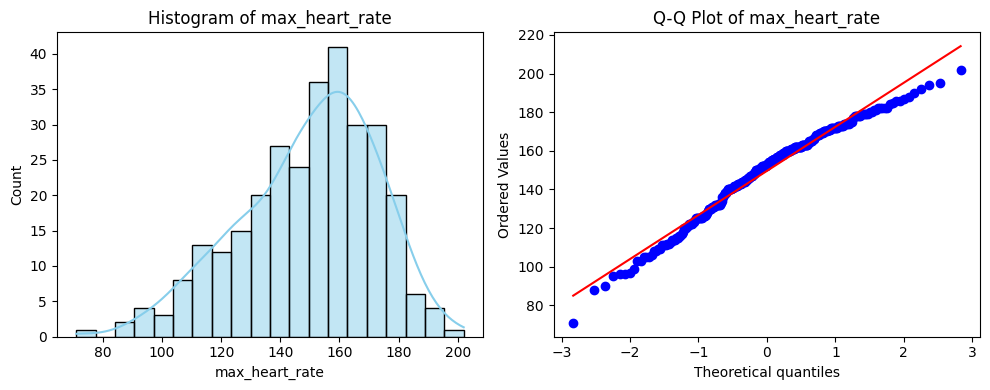

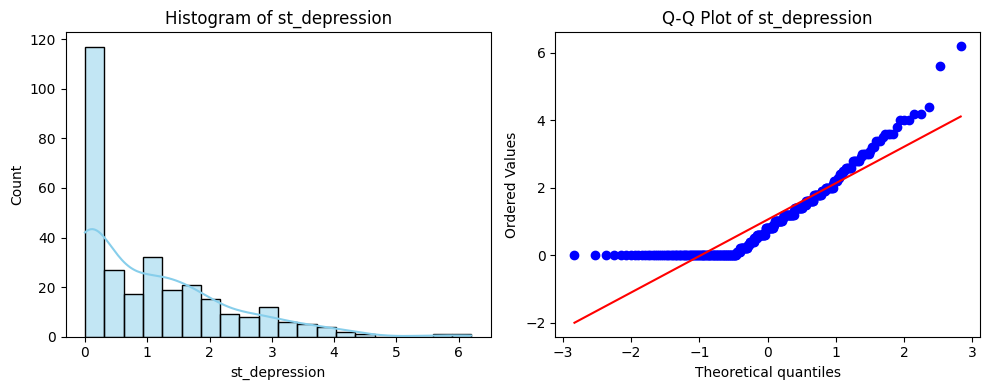

          Normality test summary          


              variable  p_shapiro shapiro_interpretation   p_ks ks_interpretation
             age_years     0.0054             Not normal 0.0483        Not normal
resting_blood_pressure     0.0000             Not normal 0.0031        Not normal
     serum_cholesterol     0.0000             Not normal 0.3741            Normal
        max_heart_rate     0.0001             Not normal 0.0829            Normal
         st_depression     0.0000             Not normal 0.0000        Not normal


In [46]:
print_box("Pruebas de normalidad en variables numéricas")

# Variables numéricas continuas (nombres nuevos en inglés)
num_cont = ["age_years", "resting_blood_pressure", "serum_cholesterol",
            "max_heart_rate", "st_depression"]

resultados = []

for col in num_cont:
    data = df[col].dropna()

    # Shapiro-Wilk (solo si n <= 5000)
    shapiro_stat, shapiro_p = stats.shapiro(data)

    # Kolmogorov-Smirnov (contra distribución normal estandarizada)
    ks_stat, ks_p = stats.kstest((data - data.mean())/data.std(ddof=0), 'norm')

    # Guardo resultados
    resultados.append({
        "variable": col,
        "shapiro_W": round(shapiro_stat, 4),
        "p_shapiro": round(shapiro_p, 4),
        "ks_stat": round(ks_stat, 4),
        "p_ks": round(ks_p, 4),
        "n": len(data)
    })

    # ----------------------------------------------------------
    # Histogramas + Q-Q plot
    # ----------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(10,4))

    # Histograma con KDE
    sns.histplot(data, bins=20, kde=True, ax=axes[0], color="skyblue", edgecolor="black")
    axes[0].set_title(f"Histogram of {col}")

    # Q-Q plot
    stats.probplot(data, dist="norm", plot=axes[1])
    axes[1].set_title(f"Q-Q Plot of {col}")

    plt.tight_layout()
    plt.show()

# Convertir resultados en DataFrame
res_df = pd.DataFrame(resultados)

# ----------------------------------------------------------
# Tabla resumen de interpretación
# ----------------------------------------------------------
# Regla: p > 0.05 -> normal | p <= 0.05 -> no normal
res_df["shapiro_interpretation"] = res_df["p_shapiro"].apply(lambda p: "Normal" if p > 0.05 else "Not normal")
res_df["ks_interpretation"] = res_df["p_ks"].apply(lambda p: "Normal" if p > 0.05 else "Not normal")

# Tabla final
print_box("Normality test summary")
print(res_df[["variable", "p_shapiro", "shapiro_interpretation", "p_ks", "ks_interpretation"]].to_string(index=False))


          Pairplot de variables numéricas con condición cardíaca          




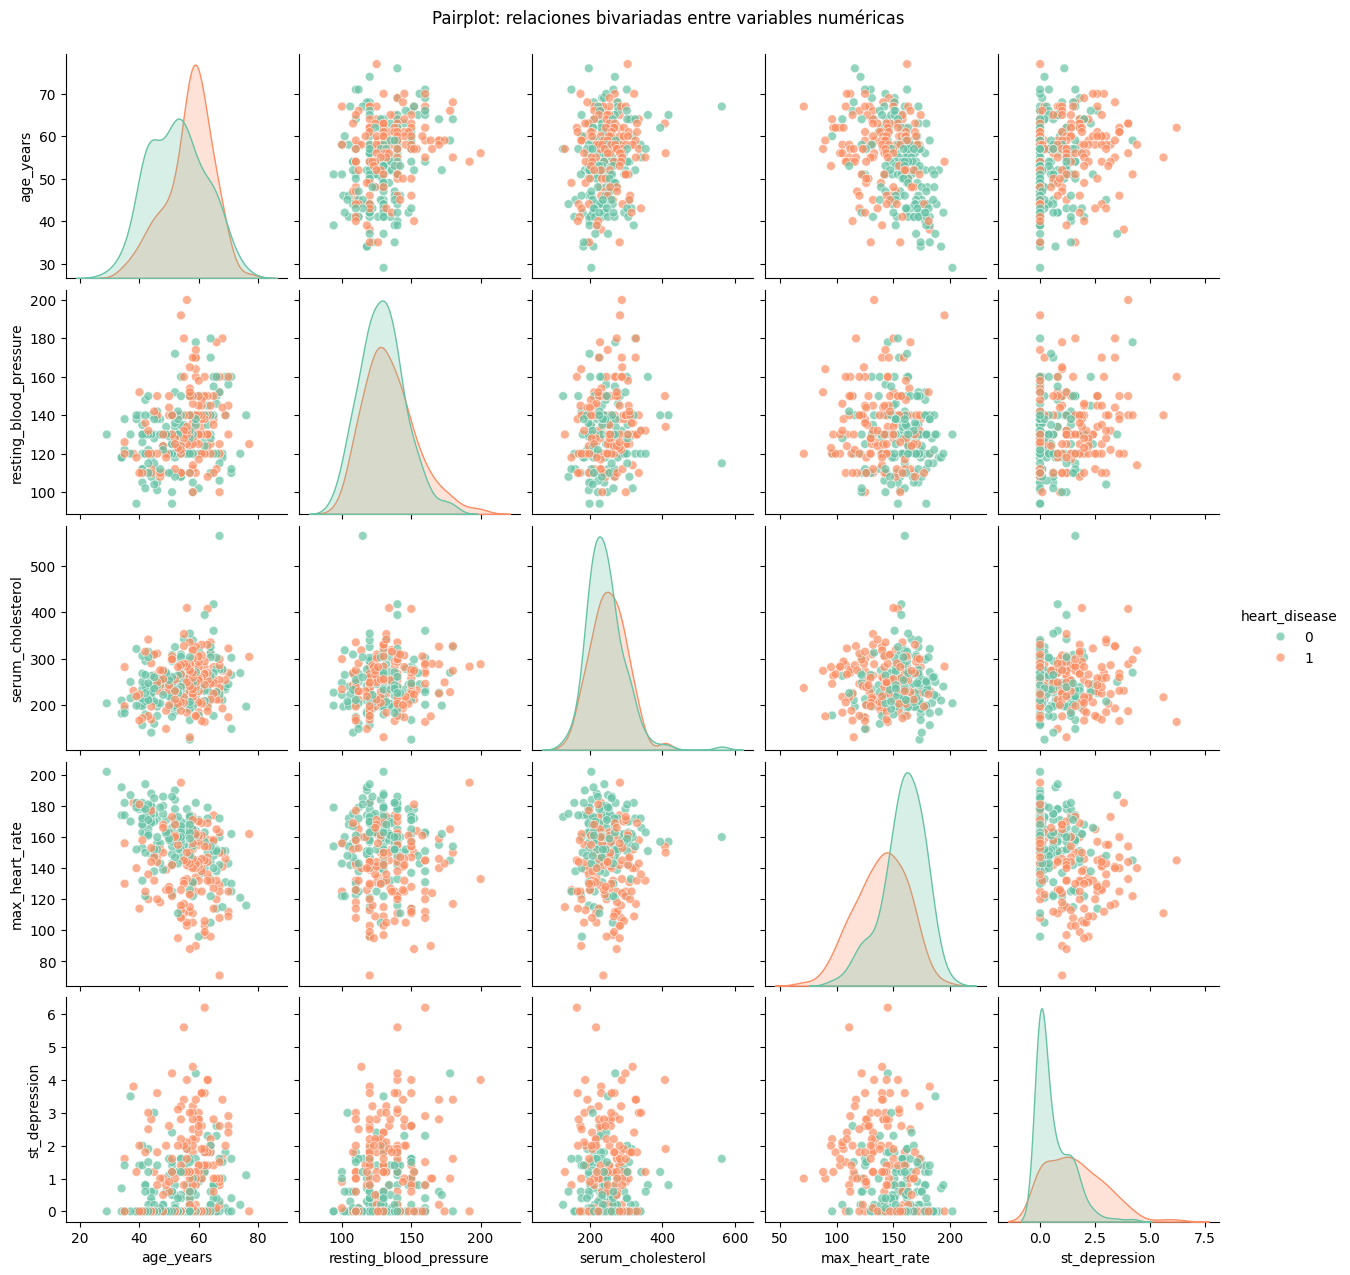

In [47]:
print_box("Pairplot de variables numéricas con condición cardíaca")

# Selecciono solo las columnas numéricas continuas + la variable objetivo
cols_pair = ["age_years", "resting_blood_pressure", "serum_cholesterol",
             "max_heart_rate", "st_depression", "heart_disease"]

# Creo el pairplot coloreando por 'heart_disease'
sns.pairplot(
    df[cols_pair],
    hue="heart_disease",
    diag_kind="kde",      # en la diagonal uso densidad (también puede ser 'hist')
    palette="Set2",
    plot_kws={"alpha":0.7, "s":40}  # transparencia y tamaño de puntos
)
plt.suptitle("Pairplot: relaciones bivariadas entre variables numéricas", y=1.02)
plt.show()


## **Preprocesamiento de los datos**

In [48]:
# Outliers conservadores en serum_cholesterol y st_depression

def detectar_outliers_iqr_conservador(data, columna, factor):
    Q1 = data[columna].quantile(0.25)   # percentil 25
    Q3 = data[columna].quantile(0.75)   # percentil 75
    IQR = Q3 - Q1                       # rango intercuartílico

    # límites más amplios
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR

    outliers = data[(data[columna] < lower) | (data[columna] > upper)]

    print_box(f"Outliers (conservadores) detectados en {columna}")
    print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"Límite inferior = {lower:.2f}, Límite superior = {upper:.2f}")
    print(f"Total de outliers detectados = {len(outliers)}")

    return outliers

# Detectar outliers conservadores
outliers_chol = detectar_outliers_iqr_conservador(df, "serum_cholesterol", factor=3.0)
outliers_st = detectar_outliers_iqr_conservador(df, "st_depression", factor=3.0)

# Mostrar algunos ejemplos
print_box("Ejemplos de outliers en serum_cholesterol (conservadores)")
print(outliers_chol[["serum_cholesterol"]].head())

print_box("Ejemplos de outliers en st_depression (conservadores)")
print(outliers_st[["st_depression"]].head())

          Outliers (conservadores) detectados en serum_cholesterol          


Q1 = 211.00, Q3 = 276.00, IQR = 65.00
Límite inferior = 16.00, Límite superior = 471.00
Total de outliers detectados = 1
          Outliers (conservadores) detectados en st_depression          


Q1 = 0.00, Q3 = 1.60, IQR = 1.60
Límite inferior = -4.80, Límite superior = 6.40
Total de outliers detectados = 0
          Ejemplos de outliers en serum_cholesterol (conservadores)          


    serum_cholesterol
79                564
          Ejemplos de outliers en st_depression (conservadores)          


Empty DataFrame
Columns: [st_depression]
Index: []


In [49]:
print("Dado que es solo un caso y el criterio fue muy conservador (factor = 3.0 × IQR), es probable que sea un valor extremo pero aún plausible en pacientes.")

Dado que es solo un caso y el criterio fue muy conservador (factor = 3.0 × IQR), es probable que sea un valor extremo pero aún plausible en pacientes.


In [50]:
# Variables numéricas continuas con los nombres renombrados
num_cols = ["age_years", "resting_blood_pressure", "serum_cholesterol", "max_heart_rate", "st_depression"]

# Creo el estandarizador
scaler = StandardScaler()

# Ajusto y transformo
df[num_cols] = scaler.fit_transform(df[num_cols])

# Muestro las primeras filas para verificar
print_box("Variables numéricas estandarizadas (Z-score)")
print(df[num_cols].head().to_string(index=False, line_width=10000))


# Verifico medias y desviaciones estándar
print_box("Media y desviación estándar después de estandarización")
print(df[num_cols].agg(["mean", "std"]).round(2).to_string(index=False, line_width=10000))


          Variables numéricas estandarizadas (Z-score)          


 age_years  resting_blood_pressure  serum_cholesterol  max_heart_rate  st_depression
  1.600302                1.596266          -0.257179       -0.812095      -0.820813
  1.600302                0.468418          -0.160859        0.061157       0.639470
  1.268242                1.032342          -0.411292       -1.554358       1.326662
  1.157555                0.355633           0.667499        1.065396       0.295874
  1.046868               -1.223355          -0.700254       -0.244481       0.639470
          Media y desviación estándar después de estandarización          


 age_years  resting_blood_pressure  serum_cholesterol  max_heart_rate  st_depression
      -0.0                     0.0               -0.0             0.0            0.0
       1.0                     1.0                1.0             1.0            1.0


          Histogramas de variables numéricas estandarizadas (Z-score)          




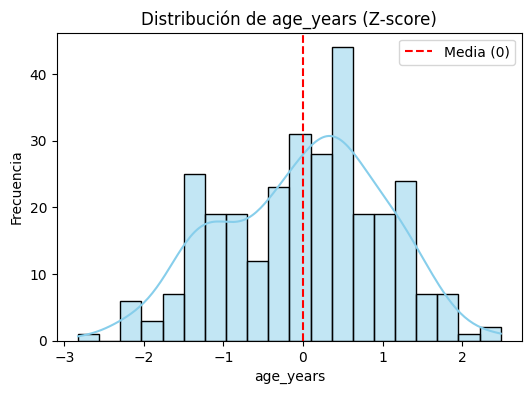

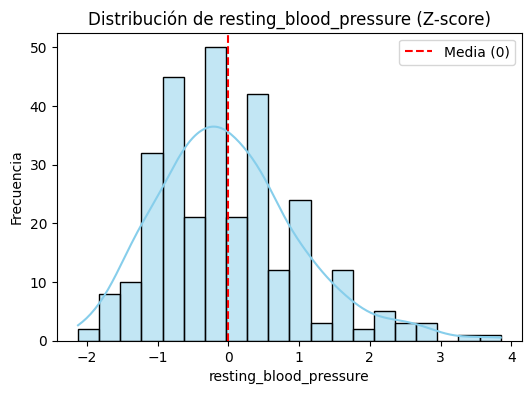

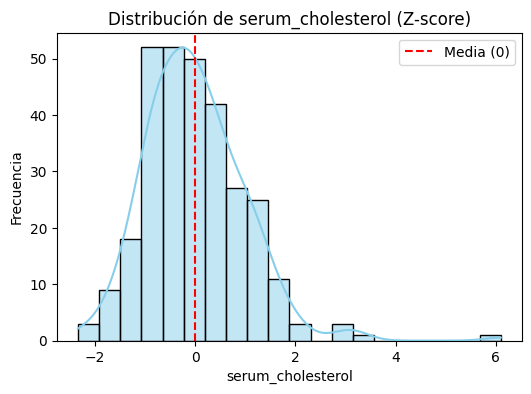

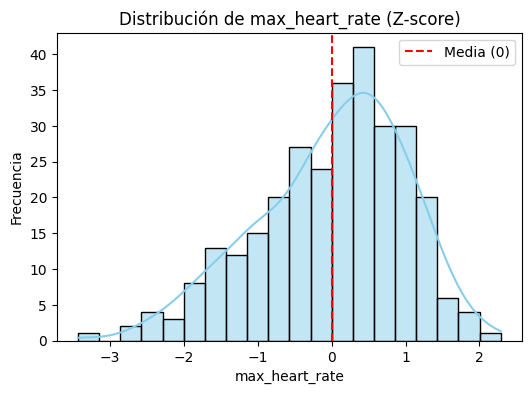

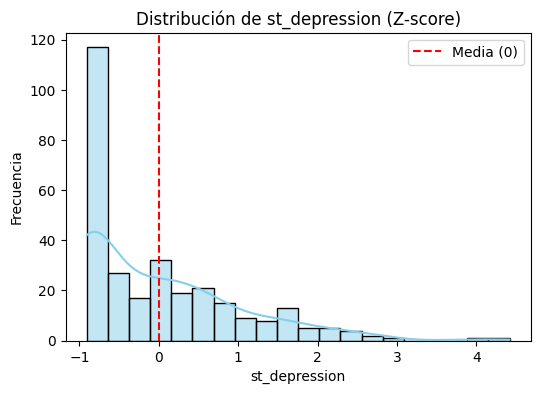

In [51]:
print_box("Histogramas de variables numéricas estandarizadas (Z-score)")

# Variables numéricas estandarizadas
num_cols = ["age_years", "resting_blood_pressure", "serum_cholesterol", "max_heart_rate", "st_depression"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True, color="skyblue", edgecolor="black")
    plt.title(f"Distribución de {col} (Z-score)")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.axvline(0, color="red", linestyle="--", label="Media (0)")
    plt.legend()
    plt.show()


## **Conclusiones parciales**

## Calidad de los datos

- El dataset presenta una buena completitud: no se detectaron valores faltantes relevantes.
- En la búsqueda de outliers, solo se identificó 1 caso extremo en serum_cholesterol, pero se determinó que es clínicamente plausible, por lo que se mantuvo sin imputación.
- Las demás variables numéricas (st_depression, resting_blood_pressure, max_heart_rate, etc.) se encuentran dentro de rangos aceptables.
- Se definieron los tipos de variables correctamente (numéricas vs categóricas), lo que evita inconsistencias en el análisis.

## Análisis descriptivo

- Aproximadamente la mitad de los pacientes presentan enfermedad cardíaca, lo que garantiza un dataset balanceado para clasificación.
- Las variables numéricas presentan distribuciones no normales, confirmadas por pruebas de Shapiro-Wilk y Kolmogorov-Smirnov.
- La variable serum_cholesterol muestra algunos valores elevados, pero aún dentro de rangos clínicamente posibles.
- La variable st_depression se distribuye mayormente cerca de cero, con pocos valores altos.

## Preprocesamiento

- Se realizó la renombración de columnas a nombres en inglés más comprensibles
- Se generaron mapeos de variables categóricas para facilitar la interpretación y el modelado.
- Se aplicó reescalado Z-score a las variables numéricas, garantizando que todas estén en la misma escala (media = 0, desviación estándar = 1).
- No se aplicaron imputaciones adicionales ni eliminación de registros, dado que los datos se encuentran en un estado confiable

## Estado de preparación del dataset

- El dataset está ahora listo para fases posteriores de análisis avanzado y modelado predictivo.
- Las variables están limpias, tipificadas y normalizadas, con un único outlier identificado y controlado en su interpretación.
- Se encuentra en condiciones de ser usado en modelos de machine learning, tanto supervisados (clasificación) como no supervisados (clustering, reducción de dimensionalidad).
